Title: Rsds_dist_comp.ipynb

Purpose: Compare the distribution of RSDS in current and future climate

Author: Onno Nennecke on 02.06.2025 Modified: 12.05.2026

Input data: 

- rsds Data from CMIP
    - These files lie here: /climca/people/onennecke/not_debiased_data_future/
- Used Runs File: CMIP6_runs.csv
    - These files lie here: /home/onennecke/CMIP_models/

Output data:

- rsds winter means Data: rsds_mean_combined.nc
    - This file lies here: /climca/people/onennecke/model_output/var_means/future_climate/Rsds_not_bc/
- rsds composite data
    - This file lies here: //climca/people/onennecke/model_output/composites

### Load libraries and functions

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import os
import glob
import time
# import cftime
import re

# Importing functions
import Functions.grid_func as grid_func

/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


### Read data

In [2]:
# Read the dataframe from the csv file
used_runs_fut = pd.read_csv('/home/onennecke/CMIP_models/CMIP6_runs_future.csv')
used_runs_CESM_LE = pd.read_csv('/home/onennecke/CMIP_models/CESM2_LE_runs.csv')


used_runs = pd.concat([used_runs_fut, used_runs_CESM_LE], ignore_index=True)

# Change the ref column to 1 for the first instance of each model
# used_runs['Ref'] = used_runs.groupby(['ESM', 'Institution']).cumcount().apply(lambda x: 1 if x == 0 else 0)

ESMs = used_runs['ESM'].unique()

In [33]:
used_runs_CESM_LE

,ESM,Institution,run
0,CESM2,NCAR,LE2-1001_001
1,CESM2,NCAR,LE2-1011_001
2,CESM2,NCAR,LE2-1021_002
3,CESM2,NCAR,LE2-1031_002
4,CESM2,NCAR,LE2-1041_003
...,...,...,...
95,CESM2,NCAR,LE2-1301_016
96,CESM2,NCAR,LE2-1301_017
97,CESM2,NCAR,LE2-1301_018
98,CESM2,NCAR,LE2-1301_019


In [41]:
base_path_fut = '/climca/people/onennecke/not_debiased_data_future/'
base_path_cur = '/climca/people/onennecke/not_debiased_data/'

# Build a list of file names from the used_runs dataframe
file_names = []
for index, row in used_runs.iterrows():
    esm = row['ESM']
    # institution = row['Institution']
    run = row['run']
    
    # Construct the file name based on the ESM, institution, and run
    file_name_pattern = f'{esm}_{run}_rsds.nc'
    
    # Append the file name pattern to the list
    file_names.append(file_name_pattern)
# file_names


In [42]:
ds_list = []
counter = 1
for file_name in file_names:
    file_path = os.path.join(base_path_cur, file_name)
    print(f'{counter}/{len(file_names)}: Processing file: {file_path}')
    if os.path.exists(file_path):
        ds = xr.open_dataset(file_path)
        esm_run = ds.ESM_run.values
        # Select only 6 winter months (October to March)
        ds = ds.sel(time=ds['time.month'].isin([10, 11, 12, 1, 2, 3]))
        
        # Calculate the spatial mean over the dimension
        mean_ds = ds.mean(dim=['lat', 'lon'], keep_attrs=True)
        
        ts_output = mean_ds.expand_dims(ESM_run=[esm_run]).assign_coords(ESM_run=[esm_run])
        ds_list.append(ts_output)
    else:
        print(f'File not found: {file_path}')
    counter += 1
Rsds_esm_ds_cur = xr.concat(ds_list, dim="ESM_run")

ds_list = []
counter = 1
for file_name in file_names:
    file_path = os.path.join(base_path_fut, file_name)
    print(f'{counter}/{len(file_names)}: Processing file: {file_path}')
    if os.path.exists(file_path):
        ds = xr.open_dataset(file_path)
        esm_run = ds.ESM_run.values
        # Select only 6 winter months (October to March)
        ds = ds.sel(time=ds['time.month'].isin([10, 11, 12, 1, 2, 3]))
        
        # Calculate the spatial mean over the dimension
        mean_ds = ds.mean(dim=['lat', 'lon'], keep_attrs=True)
        
        ts_output = mean_ds.expand_dims(ESM_run=[esm_run]).assign_coords(ESM_run=[esm_run])
        ds_list.append(ts_output)
    else:
        print(f'File not found: {file_path}')
    counter += 1
Rsds_esm_ds_fut = xr.concat(ds_list, dim="ESM_run")

1/ 192: Processing file: /climca/people/onennecke/not_debiased_data/ACCESS-CM2_r4i1p1f1_rsds.nc
2/ 192: Processing file: /climca/people/onennecke/not_debiased_data/ACCESS-CM2_r5i1p1f1_rsds.nc
3/ 192: Processing file: /climca/people/onennecke/not_debiased_data/ACCESS-CM2_r1i1p1f1_rsds.nc
4/ 192: Processing file: /climca/people/onennecke/not_debiased_data/BCC-CSM2-MR_r1i1p1f1_rsds.nc
5/ 192: Processing file: /climca/people/onennecke/not_debiased_data/CESM2_r4i1p1f1_rsds.nc
6/ 192: Processing file: /climca/people/onennecke/not_debiased_data/CESM2_r10i1p1f1_rsds.nc
7/ 192: Processing file: /climca/people/onennecke/not_debiased_data/CESM2_r11i1p1f1_rsds.nc
8/ 192: Processing file: /climca/people/onennecke/not_debiased_data/EC-Earth3_r149i1p1f1_rsds.nc
9/ 192: Processing file: /climca/people/onennecke/not_debiased_data/EC-Earth3_r4i1p1f1_rsds.nc
10/ 192: Processing file: /climca/people/onennecke/not_debiased_data/EC-Earth3_r148i1p1f1_rsds.nc
11/ 192: Processing file: /climca/people/onennecke

In [43]:
Rsds_esm_ds_cur

<xarray.Dataset> Size: 1MB
Dimensions:   (ESM_run: 192, time: 1820)
Coordinates:
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * time      (time) datetime64[ns] 15kB 2015-01-01 2015-01-02 ... 2024-12-31
    ESM       (ESM_run) <U13 10kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'CESM2_LE'
    run       (ESM_run) <U12 9kB 'r4i1p1f1' 'r5i1p1f1' ... 'LE2-1301_020'
  * ESM_run   (ESM_run) <U23 18kB 'ACCESS-CM2_r4i1p1f1' ... 'CESM2_LE_LE2-130...
Data variables:
    rsds      (ESM_run, time) float32 1MB 18.25 25.43 33.59 ... 30.38 28.05 26.4
Attributes:
    regrid_method:  bilinear

In [51]:
192*1820

349440

In [58]:
len(Rsds_esm_ds_fut['rsds'].values.ravel())
Rsds_esm_ds_fut['rsds'].values.ravel()

# Remove nans from the data
esm_data_cur = Rsds_esm_ds_cur['rsds'].values.ravel()
print(len(esm_data_cur))
esm_data_cur = esm_data_cur[~np.isnan(esm_data_cur)]
print(len(esm_data_cur))
esm_data_fut = Rsds_esm_ds_fut['rsds'].values.ravel()
print(len(esm_data_fut))
esm_data_fut = esm_data_fut[~np.isnan(esm_data_fut)]
print(len(esm_data_fut))



349440
349440
873600
349440


/tmp/ipykernel_3300701/992804625.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(esm_data_cur, labels=['Current'], positions=[0.8])
/tmp/ipykernel_3300701/992804625.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(esm_data_fut, labels=['Future'], positions=[1.2])
/tmp/ipykernel_3300701/992804625.py:12: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


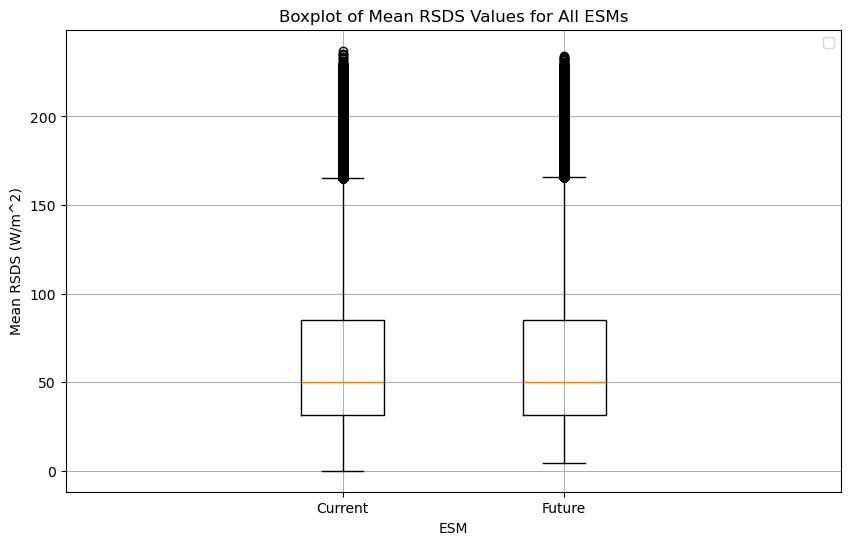

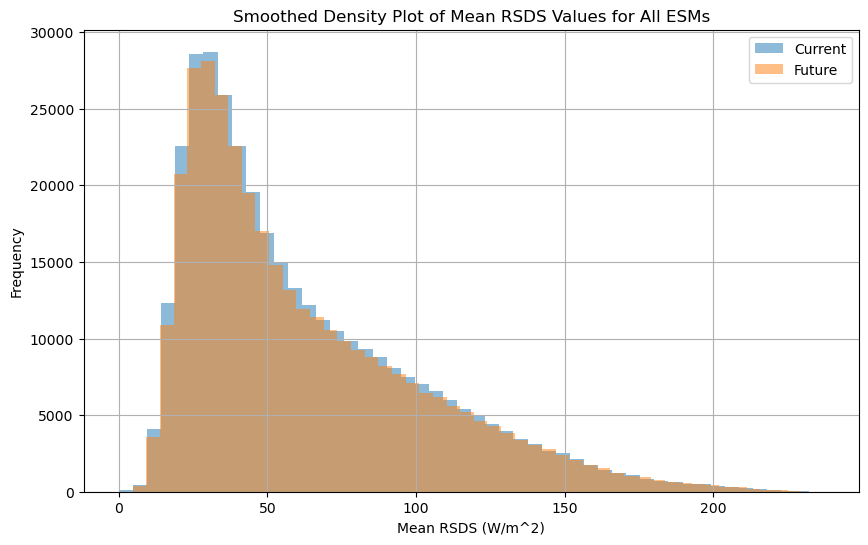

In [59]:


# Plot a boxplot plot of the mean RSDS values for all ESMs
plt.figure(figsize=(10, 6))
esm_data_cur = Rsds_esm_ds_cur['rsds'].values.ravel()
# Shift the boxplot to the left by 0.2
plt.boxplot(esm_data_cur, labels=['Current'], positions=[0.8]) 
esm_data_fut = Rsds_esm_ds_fut['rsds'].values.ravel()
esm_data_fut = esm_data_fut[~np.isnan(esm_data_fut)]
plt.boxplot(esm_data_fut, labels=['Future'], positions=[1.2])
plt.xlabel('ESM')
plt.ylabel('Mean RSDS (W/m^2)')
plt.title('Boxplot of Mean RSDS Values for All ESMs')
plt.legend()
plt.grid()
plt.show()

# Plot a smoothed density plot of the mean RSDS values for all ESMs
plt.figure(figsize=(10, 6))
plt.hist(esm_data_cur, bins=50, alpha=0.5, label='Current')
plt.hist(esm_data_fut, bins=50, alpha=0.5, label='Future')
plt.xlabel('Mean RSDS (W/m^2)')
plt.ylabel('Frequency')
plt.title('Smoothed Density Plot of Mean RSDS Values for All ESMs')
plt.legend()
plt.grid()
plt.show()


In [44]:
Rsds_esm_ds_fut

<xarray.Dataset> Size: 4MB
Dimensions:   (ESM_run: 192, time: 4550)
Coordinates:
  * time      (time) datetime64[ns] 36kB 2030-01-01 2030-01-02 ... 2054-12-31
  * ESM_run   (ESM_run) <U23 18kB 'ACCESS-CM2_r4i1p1f1' ... 'CESM2_LE_LE2-130...
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
    ESM       (ESM_run) <U13 10kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'CESM2_LE'
    run       (ESM_run) <U12 9kB 'r4i1p1f1' 'r5i1p1f1' ... 'LE2-1301_020'
Data variables:
    rsds      (ESM_run, time) float32 3MB nan nan nan nan ... nan nan nan nan
Attributes:
    regrid_method:  bilinear

In [48]:
np.unique(Rsds_esm_ds_cur.ESM.values)

array(['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'CESM2_LE', 'EC-Earth3',
       'GFDL-ESM4', 'KACE-1-0-G', 'MPI-ESM1-2-HR', 'MRI-ESM2-0',
       'TaiESM1', 'UKESM1-0-LL'], dtype='<U13')

In [63]:
Rsds_esm_ds_cur

<xarray.Dataset> Size: 1MB
Dimensions:   (ESM_run: 192, time: 1820)
Coordinates:
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * time      (time) datetime64[ns] 15kB 2015-01-01 2015-01-02 ... 2024-12-31
    ESM       (ESM_run) <U13 10kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'CESM2_LE'
    run       (ESM_run) <U12 9kB 'r4i1p1f1' 'r5i1p1f1' ... 'LE2-1301_020'
  * ESM_run   (ESM_run) <U23 18kB 'ACCESS-CM2_r4i1p1f1' ... 'CESM2_LE_LE2-130...
Data variables:
    rsds      (ESM_run, time) float32 1MB 18.25 25.43 33.59 ... 30.38 28.05 26.4
Attributes:
    regrid_method:  bilinear

In [ ]:
esm_data_cur_dict = {}
esm_data_fut_dict = {}

esm_data_cur_dict['All'] = Rsds_esm_ds_cur['rsds'].values.ravel()
esm_data_fut = Rsds_esm_ds_fut['rsds'].values.ravel()
esm_data_fut = esm_data_fut[~np.isnan(esm_data_fut)]
esm_data_fut_dict['All'] = esm_data_fut

for esm in np.unique(Rsds_esm_ds_cur.ESM.values):
    esm_data_cur = Rsds_esm_ds_cur.where(Rsds_esm_ds_cur.ESM == esm)['rsds'].values.ravel()
    esm_data_cur = esm_data_cur[~np.isnan(esm_data_cur)]
    esm_data_cur_dict[esm] = esm_data_cur
    esm_data_fut = Rsds_esm_ds_fut.where(Rsds_esm_ds_fut.ESM == esm)['rsds'].values.ravel()
    esm_data_fut = esm_data_fut[~np.isnan(esm_data_fut)]
    esm_data_fut_dict[esm] = esm_data_fut
    # break


In [77]:
esm_data_cur_dict.keys()

for key in esm_data_cur_dict.keys():
    print(f'{key}: {len(esm_data_cur_dict[key])} values')
    print(f'{key}: {len(esm_data_cur_dict[key]) / 1820} values')

All: 349440 values
All: 192.0 values
ACCESS-CM2: 5460 values
ACCESS-CM2: 3.0 values
BCC-CSM2-MR: 1820 values
BCC-CSM2-MR: 1.0 values
CESM2: 5460 values
CESM2: 3.0 values
CESM2_LE: 182000 values
CESM2_LE: 100.0 values
EC-Earth3: 98280 values
EC-Earth3: 54.0 values
GFDL-ESM4: 1820 values
GFDL-ESM4: 1.0 values
KACE-1-0-G: 5460 values
KACE-1-0-G: 3.0 values
MPI-ESM1-2-HR: 18200 values
MPI-ESM1-2-HR: 10.0 values
MRI-ESM2-0: 9100 values
MRI-ESM2-0: 5.0 values
TaiESM1: 1820 values
TaiESM1: 1.0 values
UKESM1-0-LL: 20020 values
UKESM1-0-LL: 11.0 values


/tmp/ipykernel_3300701/1623688035.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(['Current', 'Future'])
/tmp/ipykernel_3300701/1623688035.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(['Current', 'Future'])
/tmp/ipykernel_3300701/1623688035.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(['Current', 'Future'])
/tmp/ipykernel_3300701/1623688035.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(['Current', 'Future'])
/tmp/ipykernel_3300701/1623688035.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() 

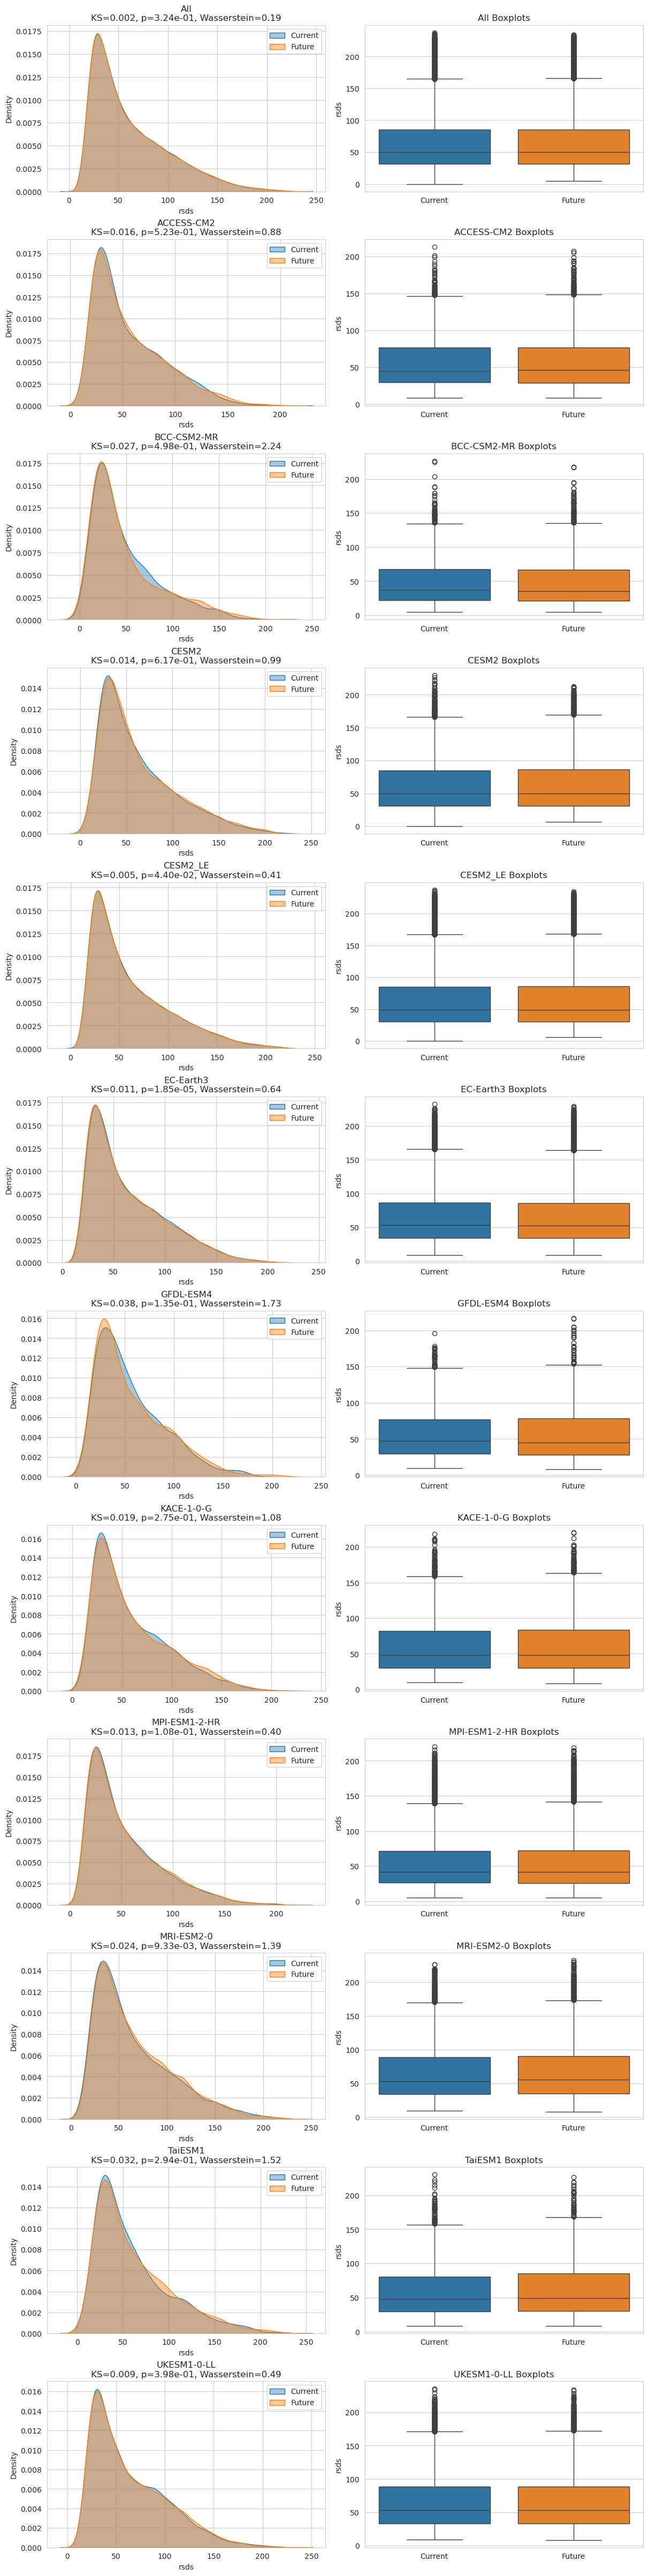

In [78]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp, wasserstein_distance

sns.set_style("whitegrid")

all_keys = list(esm_data_cur_dict.keys())

n = len(all_keys)

fig, axes = plt.subplots(
    nrows=n,
    ncols=2,
    figsize=(12, 4 * n),
    constrained_layout=True
)

# handle case n=1
if n == 1:
    axes = np.array([axes])

for i, esm in enumerate(all_keys):

    cur = esm_data_cur_dict[esm]
    fut = esm_data_fut_dict[esm]

    # -------------------------
    # KDE plot
    # -------------------------
    ax = axes[i, 0]

    sns.kdeplot(cur, ax=ax, label='Current', fill=True, alpha=0.4)
    sns.kdeplot(fut, ax=ax, label='Future', fill=True, alpha=0.4)

    # metrics
    ks_stat, ks_p = ks_2samp(cur, fut)
    wass = wasserstein_distance(cur, fut)

    ax.set_title(
        f"{esm}\nKS={ks_stat:.3f}, p={ks_p:.2e}, Wasserstein={wass:.2f}"
    )
    ax.set_xlabel("rsds")
    ax.legend()

    # -------------------------
    # Boxplot
    # -------------------------
    ax2 = axes[i, 1]

    sns.boxplot(
        data=[cur, fut],
        ax=ax2
    )

    ax2.set_xticklabels(['Current', 'Future'])
    ax2.set_title(f"{esm} Boxplots")
    ax2.set_ylabel("rsds")

plt.show()

/tmp/ipykernel_3300701/1717194014.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Current', 'Future'])
/tmp/ipykernel_3300701/1717194014.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Current', 'Future'])
/tmp/ipykernel_3300701/1717194014.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Current', 'Future'])
/tmp/ipykernel_3300701/1717194014.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Current', 'Future'])
/tmp/ipykernel_3300701/1717194014.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or u

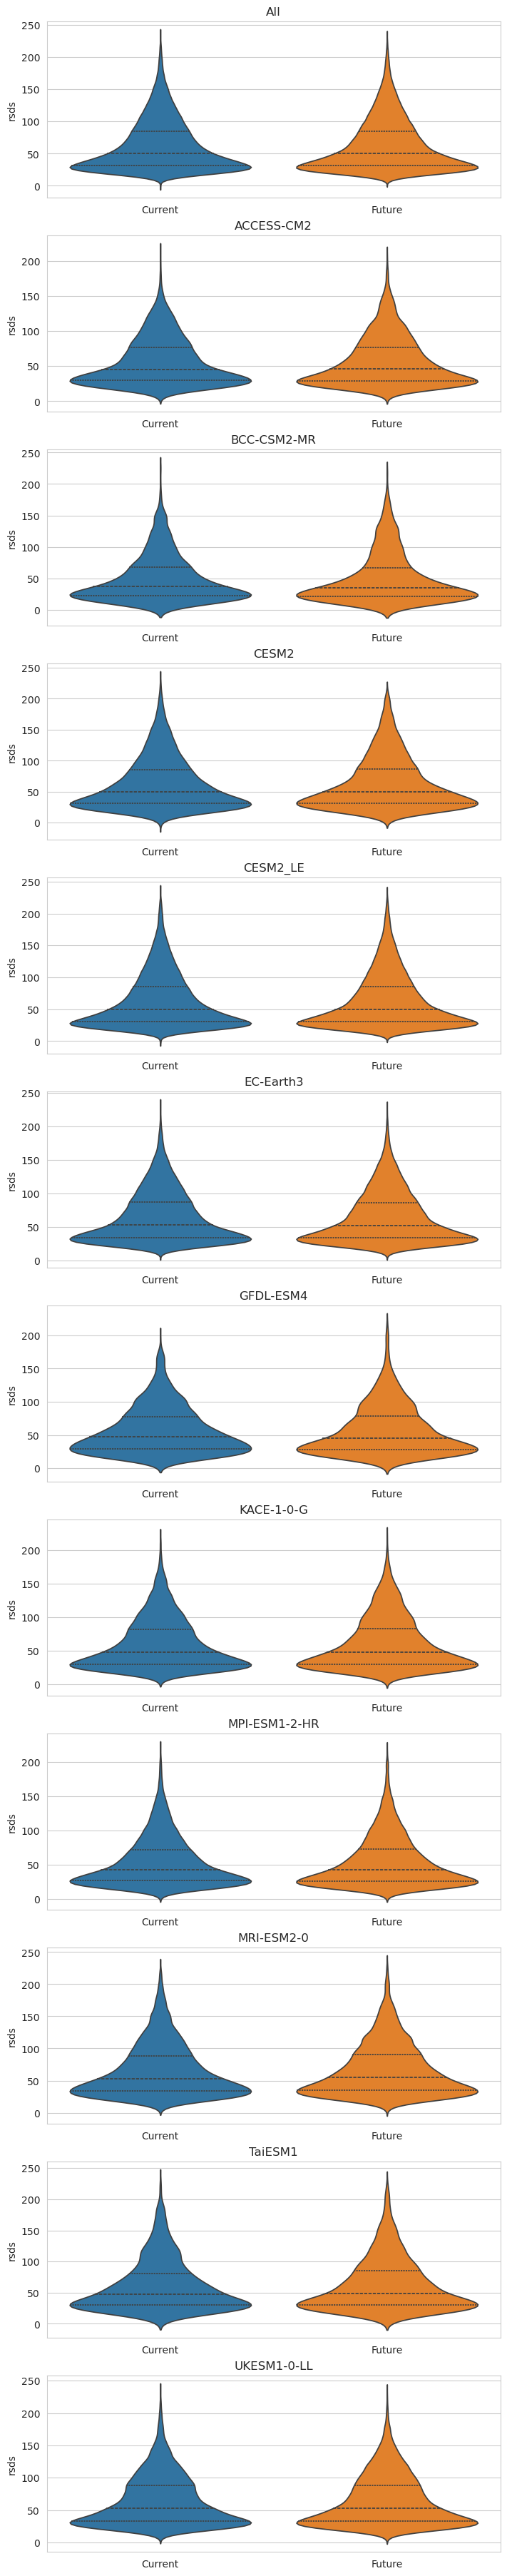

In [79]:
fig, axes = plt.subplots(
    nrows=len(all_keys),
    figsize=(7, 3 * len(all_keys)),
    constrained_layout=True
)

if len(all_keys) == 1:
    axes = [axes]

for ax, esm in zip(axes, all_keys):

    cur = esm_data_cur_dict[esm]
    fut = esm_data_fut_dict[esm]

    sns.violinplot(
        data=[cur, fut],
        ax=ax,
        inner='quartile'
    )

    ax.set_xticklabels(['Current', 'Future'])
    ax.set_title(esm)
    ax.set_ylabel("rsds")

plt.show()

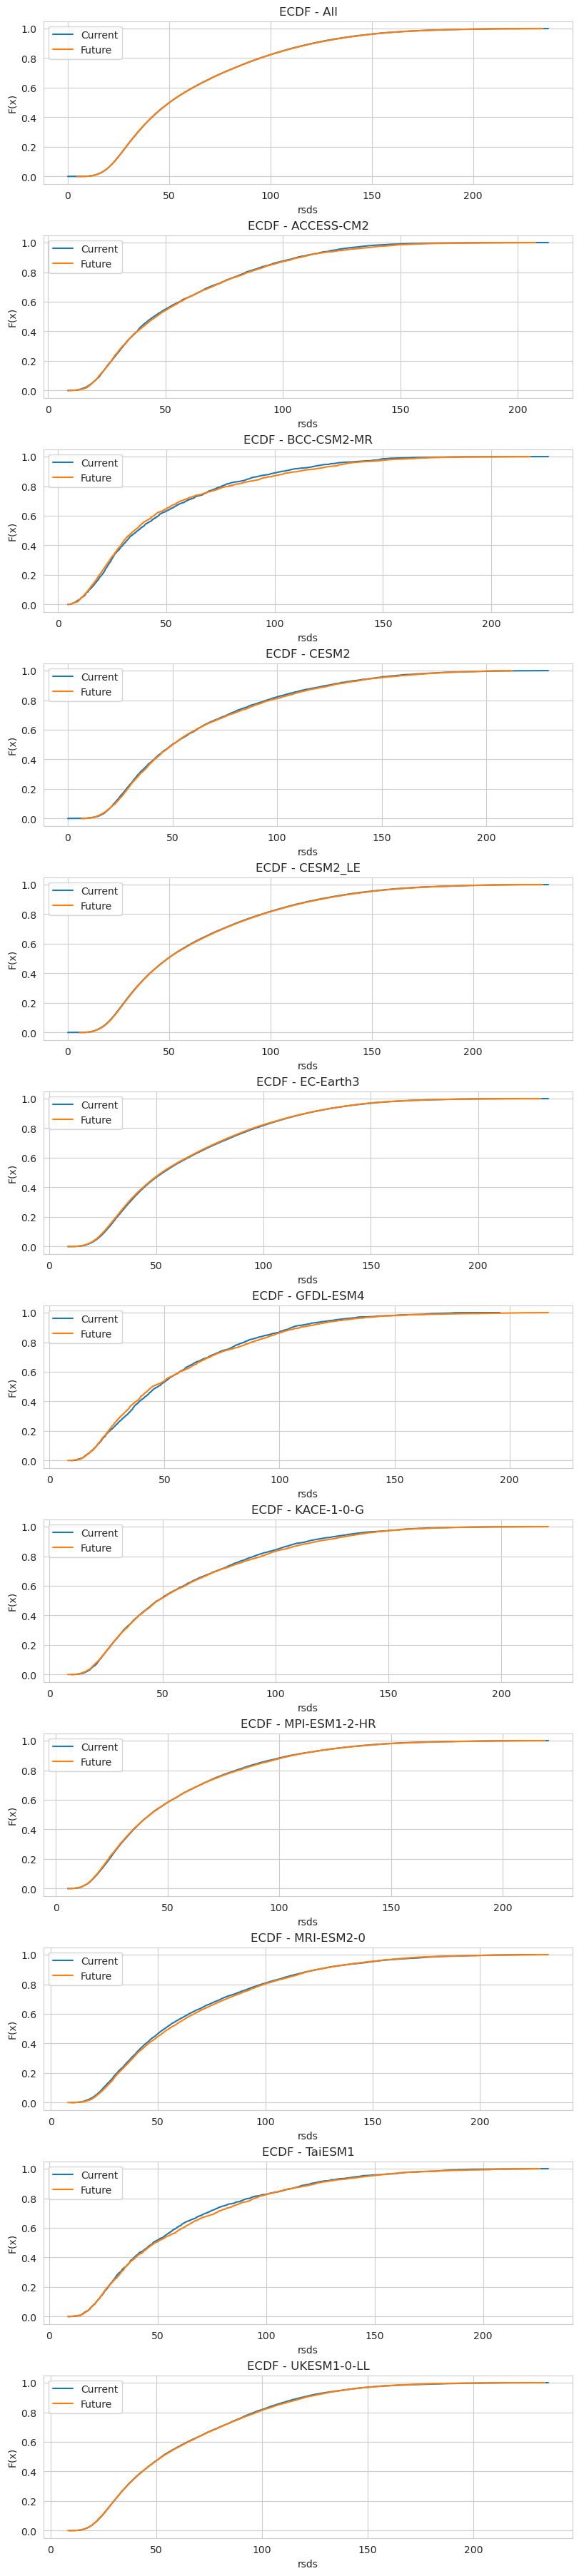

In [80]:
fig, axes = plt.subplots(
    nrows=len(all_keys),
    figsize=(8, 3 * len(all_keys)),
    constrained_layout=True
)

if len(all_keys) == 1:
    axes = [axes]

for ax, esm in zip(axes, all_keys):

    cur = np.sort(esm_data_cur_dict[esm])
    fut = np.sort(esm_data_fut_dict[esm])

    ecdf_cur = np.arange(1, len(cur)+1) / len(cur)
    ecdf_fut = np.arange(1, len(fut)+1) / len(fut)

    ax.plot(cur, ecdf_cur, label='Current')
    ax.plot(fut, ecdf_fut, label='Future')

    ax.set_title(f"ECDF - {esm}")
    ax.set_xlabel("rsds")
    ax.set_ylabel("F(x)")
    ax.legend()

plt.show()

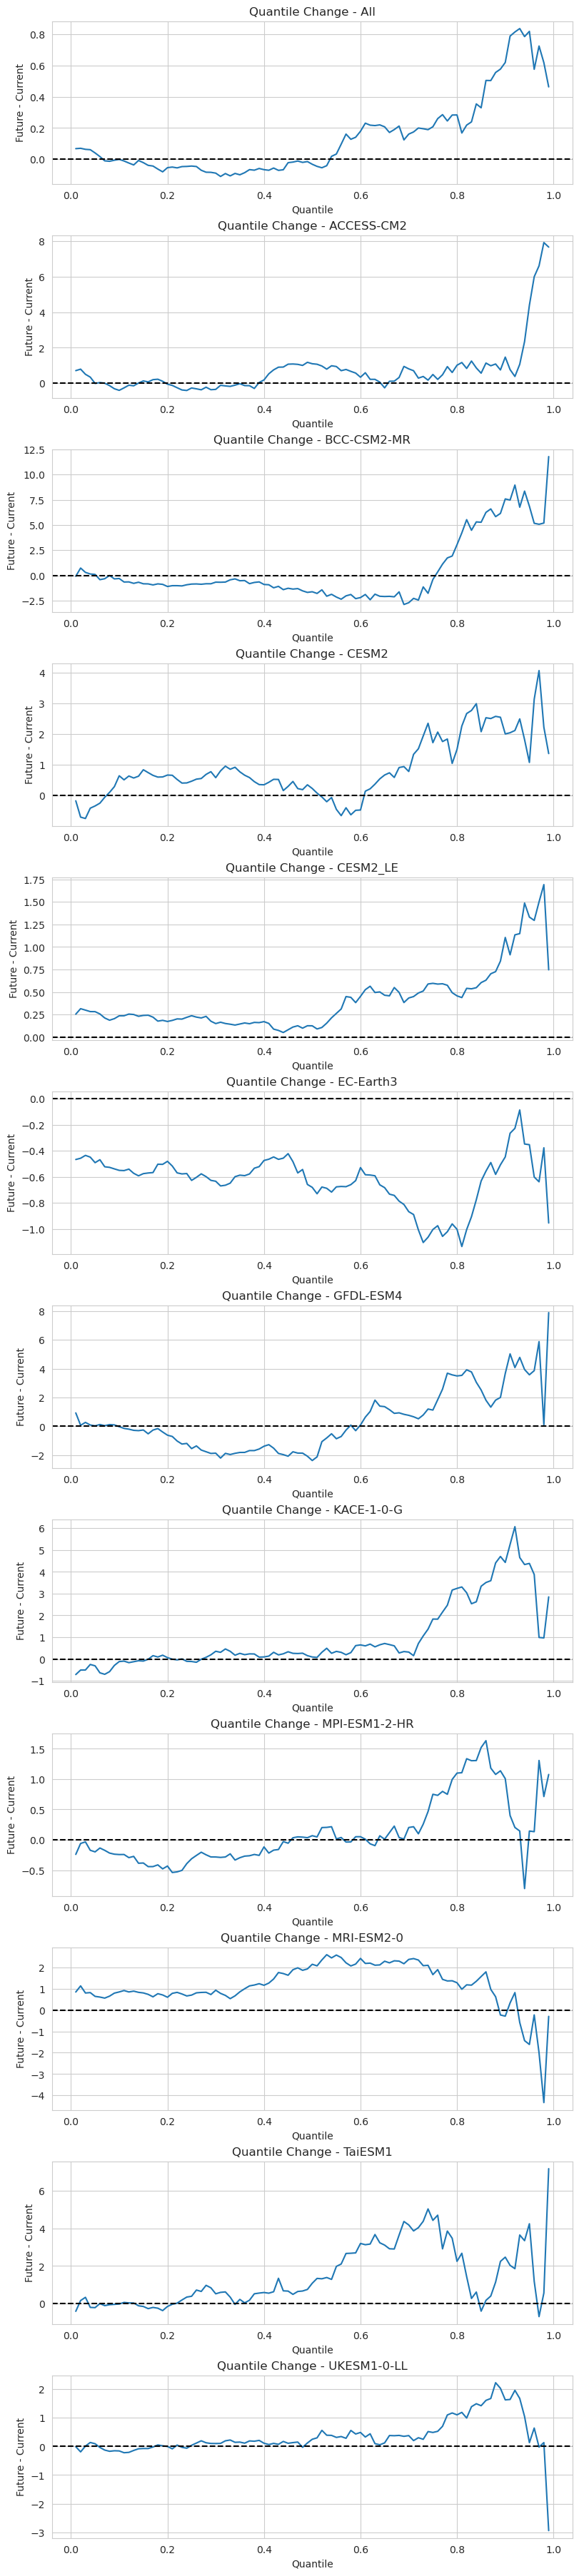

In [81]:
quantiles = np.linspace(0.01, 0.99, 99)

fig, axes = plt.subplots(
    nrows=len(all_keys),
    figsize=(8, 3 * len(all_keys)),
    constrained_layout=True
)

if len(all_keys) == 1:
    axes = [axes]

for ax, esm in zip(axes, all_keys):

    cur_q = np.quantile(esm_data_cur_dict[esm], quantiles)
    fut_q = np.quantile(esm_data_fut_dict[esm], quantiles)

    delta = fut_q - cur_q

    ax.plot(quantiles, delta)

    ax.axhline(0, color='black', linestyle='--')

    ax.set_title(f"Quantile Change - {esm}")
    ax.set_xlabel("Quantile")
    ax.set_ylabel("Future - Current")

plt.show()

In [82]:
import pandas as pd
from scipy.stats import ks_2samp, wasserstein_distance

rows = []

for esm in all_keys:

    cur = esm_data_cur_dict[esm]
    fut = esm_data_fut_dict[esm]

    ks_stat, ks_p = ks_2samp(cur, fut)

    rows.append({
        'ESM': esm,
        'Current Mean': np.mean(cur),
        'Future Mean': np.mean(fut),
        'Delta Mean': np.mean(fut) - np.mean(cur),
        'Current Std': np.std(cur),
        'Future Std': np.std(fut),
        'KS Statistic': ks_stat,
        'KS p-value': ks_p,
        'Wasserstein': wasserstein_distance(cur, fut),
    })

summary_df = pd.DataFrame(rows)

print(summary_df)

              ESM  Current Mean  Future Mean  Delta Mean  Current Std  \
0             All     62.332550    62.472652    0.140102    39.522038   
1      ACCESS-CM2     55.856506    56.614651    0.758144    33.411209   
2     BCC-CSM2-MR     49.139748    49.588230    0.448483    36.385433   
3           CESM2     62.526478    63.341873    0.815395    40.803673   
4        CESM2_LE     62.300858    62.706257    0.405399    41.111378   
5       EC-Earth3     64.362198    63.728191   -0.634007    37.479275   
6       GFDL-ESM4     56.440063    56.952591    0.512527    34.414986   
7      KACE-1-0-G     59.469284    60.410496    0.941212    37.048710   
8   MPI-ESM1-2-HR     53.371593    53.509102    0.137508    35.571526   
9      MRI-ESM2-0     65.424522    66.588623    1.164101    40.386757   
10        TaiESM1     60.984856    62.404171    1.419315    40.546608   
11    UKESM1-0-LL     63.749775    64.065437    0.315662    38.322849   

    Future Std  KS Statistic  KS p-value  Wasserst

/tmp/ipykernel_3300701/3992580031.py:10: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


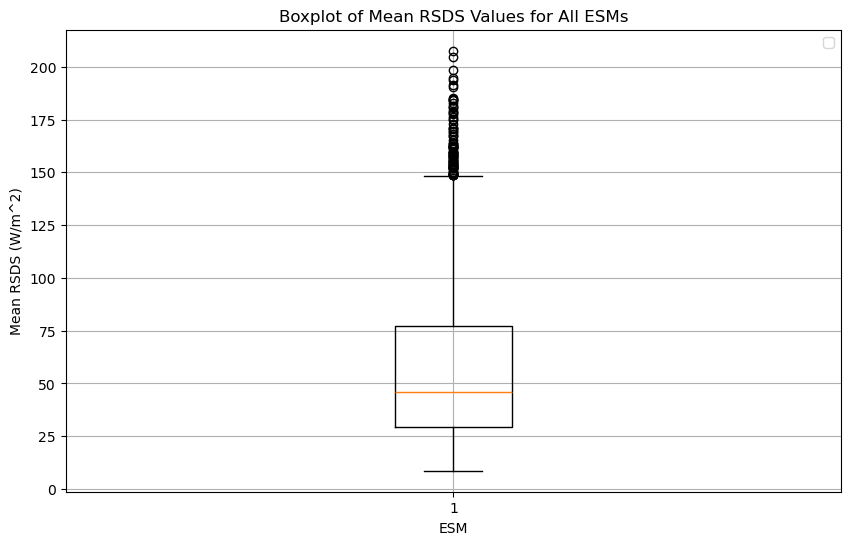

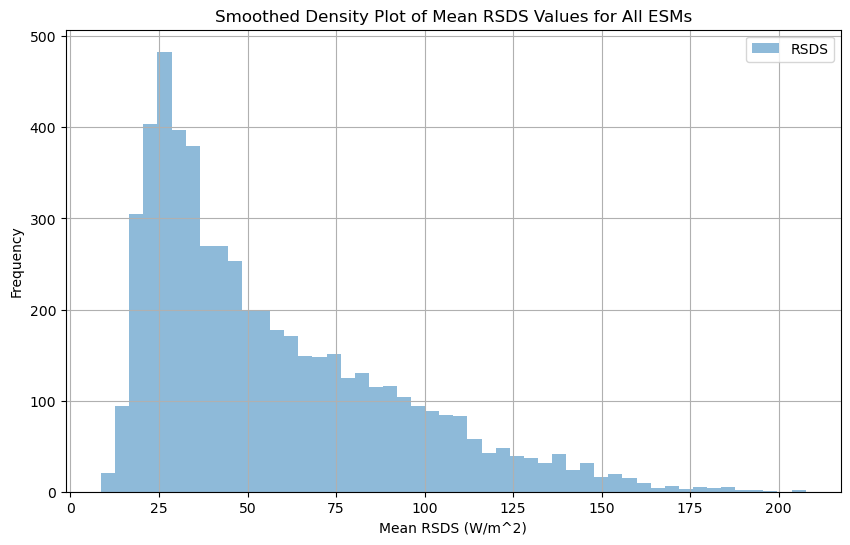

In [ ]:


# Plot a boxplot plot of the mean RSDS values for all ESMs
plt.figure(figsize=(10, 6))
for esm in np.unique(Rsds_esm_ds_cur.ESM.values):
    esm_data = Rsds_esm_ds_cur['rsds'].values.ravel()
plt.boxplot(esm_data)
plt.xlabel('ESM')
plt.ylabel('Mean RSDS (W/m^2)')
plt.title('Boxplot of Mean RSDS Values for All ESMs')
plt.legend()
plt.grid()
plt.show()

# Plot a smoothed density plot of the mean RSDS values for all ESMs
plt.figure(figsize=(10, 6))
esm_data = Rsds_esm_ds['rsds'].values.ravel()
plt.hist(esm_data, bins=50, alpha=0.5, label='RSDS')
plt.xlabel('Mean RSDS (W/m^2)')
plt.ylabel('Frequency')
plt.title('Smoothed Density Plot of Mean RSDS Values for All ESMs')
plt.legend()
plt.grid()
plt.show()


---

In [8]:
path = '/climca/people/onennecke/model_output/var_means/future_climate/Rsds_not_bc/winter'
files = sorted(glob.glob(os.path.join(path, '*.nc')))

files
ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM')

ts_datasets.load()

<xarray.Dataset> Size: 4kB
Dimensions:   (ESM: 10, lat: 9, lon: 10)
Coordinates:
  * ESM       (ESM) <U13 520B 'ACCESS-CM2' 'BCC-CSM2-MR' ... 'UKESM1-0-LL'
  * lat       (lat) int64 72B 47 48 49 50 51 52 53 54 55
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 80B 6 7 8 9 10 11 12 13 14 15
Data variables:
    rsds      (ESM, lat, lon) float32 4kB 70.23 71.73 73.32 ... 49.42 48.82

---

In [9]:
# Add one combinded dataset for all ESMs as a new ESM variable called 'combined'
ts_combined = ts_datasets.mean(dim='ESM', keep_attrs=True)
ts_combined = ts_combined.assign_coords(ESM='Combined')
# Combine the datasets
ts_datasets = xr.concat([ts_datasets, ts_combined], dim='ESM')
ts_datasets.ESM

<xarray.DataArray 'ESM' (ESM: 11)> Size: 572B
array(['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'EC-Earth3', 'GFDL-ESM4',
       'KACE-1-0-G', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'TaiESM1', 'UKESM1-0-LL',
       'Combined'], dtype='<U13')
Coordinates:
  * ESM       (ESM) <U13 572B 'ACCESS-CM2' 'BCC-CSM2-MR' ... 'Combined'
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'

In [10]:
encoding = {}

all_vars = {**ts_datasets.data_vars, **ts_datasets.coords}

for var, da in all_vars.items():
    if da.dtype.kind in {"U", "S"}:
        values = da.values.astype(str)
        if values.ndim == 0:
            maxlen = len(str(values))
        else:
            maxlen = max(map(len, values.flatten()))
        encoding[var] = {"dtype": f"U{maxlen}"}
encoding

{'ESM': {'dtype': 'U13'}, 'gridtype': {'dtype': 'U6'}}

In [11]:
# Save the combined dataset
ts_datasets.to_netcdf('/climca/people/onennecke/model_output/var_means/future_climate/Rsds_not_bc/Rsds_mean_combined.nc', encoding=encoding)

In [13]:
# Open the combined dataset
ts_combined = xr.open_dataset('/climca/people/onennecke/model_output/var_means/future_climate/Rsds_not_bc/Rsds_mean_combined.nc')
ts_combined.load()

<xarray.Dataset> Size: 5kB
Dimensions:   (ESM: 11, lat: 9, lon: 10)
Coordinates:
  * ESM       (ESM) <U13 572B 'ACCESS-CM2' 'BCC-CSM2-MR' ... 'Combined'
  * lat       (lat) int64 72B 47 48 49 50 51 52 53 54 55
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 80B 6 7 8 9 10 11 12 13 14 15
Data variables:
    rsds      (ESM, lat, lon) float32 4kB 70.23 71.73 73.32 ... 47.27 47.11

#### Plot

In [7]:
lon_edges = ts_combined.lon.values
lat_edges = ts_combined.lat.values

def setup_gridlines(ax, deg = 2, alpha = 0.4, ll = True, bl = True, label_size = 10):
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=alpha)
    gl.top_labels = False
    gl.right_labels = False
    if not ll:
        gl.left_labels = False
    if not bl:
        gl.bottom_labels = False
    gl.xlabel_style = {'size': label_size}
    gl.ylabel_style = {'size': label_size}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(deg)
    gl.ylocator = MultipleLocator(deg)
    xticks = np.arange(lon_edges.min(), lon_edges.max() + deg, deg)
    yticks = np.arange(lat_edges.min() + 1, lat_edges.max() + deg, deg)
    ax.set_xticks(xticks, crs=ccrs.PlateCarree())
    ax.set_yticks(yticks, crs=ccrs.PlateCarree())
    # only draw ticks on the bottom & left
    ax.xaxis.set_ticks_position('bottom')
    ax.yaxis.set_ticks_position('left')
    ax.tick_params(labelbottom=False, labelleft=False, labelsize=10)

/tmp/ipykernel_2959621/772748121.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.97])  # Leave space for colorbar and title


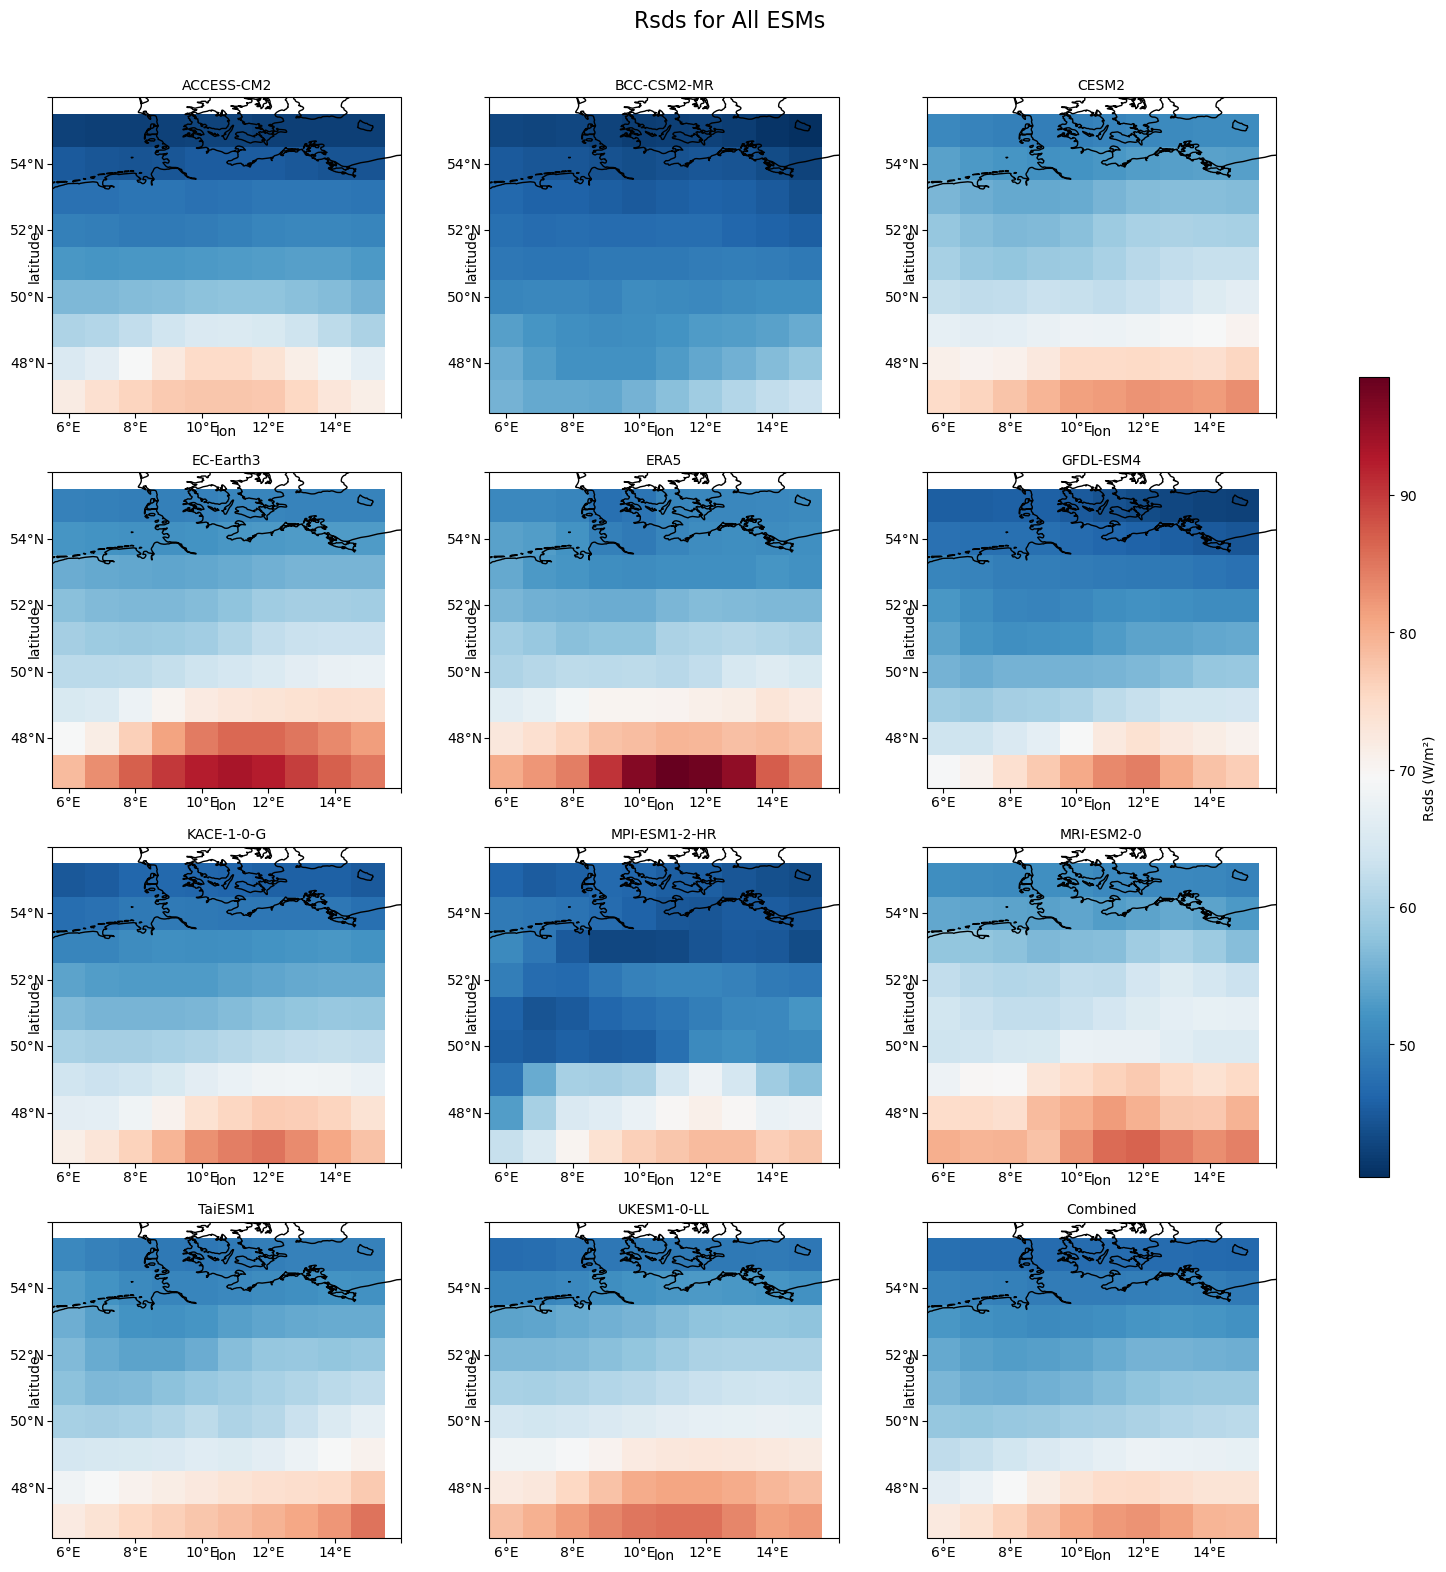

In [8]:
# Define vmin and vmax once
vmin = ts_combined['rsds'].where(ts_combined['rsds'] > 0).min()
vmax = ts_combined['rsds'].max()

# Get ESM list and determine subplot layout
esm_list = ts_combined.ESM.values
n = len(esm_list)

# Choose rows/cols for subplot grid (auto-fit)
ncols = 3
nrows = (n + ncols - 1) // ncols  # ceil division

# Create a big figure
fig, axes = plt.subplots(nrows=nrows, ncols=ncols,
                         figsize=(5 * ncols, 4 * nrows),
                         subplot_kw={'projection': ccrs.PlateCarree()})

# Flatten axes for easier indexing (handles both 1D/2D cases)
axes = axes.flatten()

for i, ESM in enumerate(esm_list):
    # print('ESM:', ESM)
    ds = ts_combined.sel(ESM=ESM)
    
    # Shift longitudes
    new_lon = ((ds['rsds'].lon + 180) % 360) - 180
    da2 = ds['rsds'].assign_coords(lon=new_lon)

    # Plot on respective axis
    ax = axes[i]
    p = da2.plot(ax=ax, transform=ccrs.PlateCarree(),
                 cmap='RdBu_r', add_colorbar=False,
                 vmin=vmin, vmax=vmax)

    ax.coastlines()
    setup_gridlines(ax, deg=2, alpha=0)
    ax.set_title(f'{ESM}', fontsize=10)

# Remove unused axes if any
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Add one shared colorbar
cbar_ax = fig.add_axes([0.92, 0.25, 0.02, 0.5])  # [left, bottom, width, height]
plt.colorbar(p, cax=cbar_ax, label='Rsds (W/m²)')

fig.suptitle('Rsds for All ESMs', fontsize=16)
plt.tight_layout(rect=[0, 0, 0.9, 0.97])  # Leave space for colorbar and title
plt.show()

## Calculate Anomaly

In [9]:
xr.open_mfdataset(Rsds_files[0]).load()

<xarray.Dataset> Size: 1MB
Dimensions:   (time: 3650, lat: 9, lon: 10)
Coordinates:
  * lat       (lat) int64 72B 47 48 49 50 51 52 53 54 55
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 80B 6 7 8 9 10 11 12 13 14 15
  * time      (time) datetime64[ns] 29kB 2015-01-01 2015-01-02 ... 2024-12-31
    ESM       <U9 36B 'EC-Earth3'
    run       <U10 40B 'r113i1p1f1'
    ESM_run   <U20 80B 'EC-Earth3_r113i1p1f1'
Data variables:
    rsds      (time, lat, lon) float32 1MB 66.41 71.62 72.53 ... 8.327 10.07
Attributes:
    regrid_method:  bilinear

In [10]:
for rsds_fl in Rsds_files:
    run_time = time.time()
    nc = xr.open_mfdataset(rsds_fl)
    ESM = nc.ESM.values
    run = nc.run.values
    print(f'Processing {ESM}, {run}')
    # if ESM == 'EC-Earth3' and run == 'r131i1p1f1':
    #     print('Skipping EC-Earth3, r131i1p1f1')
    #     continue

    # Filter to only winter months (October to March)
    nc = nc.sel(time=nc.time.dt.month.isin([10, 11, 12, 1, 2, 3]))
    rsds_anomaly = nc.copy()
    # Calculate anomaly
    rsds_anomaly['rsds'] = nc['rsds'] - ts_combined.sel(ESM = ESM)['rsds']

    ts_output = rsds_anomaly.assign_coords(run = run, ESM = ESM, ESM_run = f'{ESM}_{run}')
    ts_output.load()
    ts_output.to_netcdf(f'/climca/people/onennecke/model_output/rsds_anomaly/not_bc/{ESM}_{run}_rsds_anomaly.nc')
    # break


Processing EC-Earth3, r113i1p1f1
Processing EC-Earth3, r124i1p1f1
Processing EC-Earth3, r114i1p1f1
Processing UKESM1-0-LL, r15i1p1f2
Processing EC-Earth3, r127i1p1f1
Processing EC-Earth3, r141i1p1f1
Processing EC-Earth3, r134i1p1f1
Processing MRI-ESM2-0, r2i1p1f1
Processing UKESM1-0-LL, r10i1p1f2
Processing UKESM1-0-LL, r13i1p1f2
Processing UKESM1-0-LL, r2i1p1f2
Processing CESM2, r4i1p1f1
Processing MPI-ESM1-2-HR, r5i1p1f1
Processing EC-Earth3, r130i1p1f1
Processing EC-Earth3, r5i1p1f1
Processing UKESM1-0-LL, r4i1p1f2
Processing UKESM1-0-LL, r12i1p1f2
Processing EC-Earth3, r131i1p1f1
Processing EC-Earth3, r109i1p1f1
Processing ACCESS-CM2, r5i1p1f1
Processing MPI-ESM1-2-HR, r1i1p1f1
Processing EC-Earth3, r146i1p1f1
Processing BCC-CSM2-MR, r1i1p1f1
Processing MPI-ESM1-2-HR, r9i1p1f1
Processing TaiESM1, r1i1p1f1
Processing EC-Earth3, r107i1p1f1
Processing MRI-ESM2-0, r1i1p1f1
Processing EC-Earth3, r144i1p1f1
Processing EC-Earth3, r126i1p1f1
Processing EC-Earth3, r123i1p1f1
Processing ACCE

### Load data again

In [11]:
path = '/climca/people/onennecke/model_output/rsds_anomaly/not_bc/'

files = sorted(glob.glob(os.path.join(path, '*.nc')))
ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim='ESM_run')

ts_datasets

<xarray.Dataset> Size: 66MB
Dimensions:   (ESM_run: 100, time: 1820, lat: 9, lon: 10)
Coordinates:
  * lat       (lat) int64 72B 47 48 49 50 51 52 53 54 55
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 80B 6 7 8 9 10 11 12 13 14 15
  * time      (time) datetime64[ns] 15kB 2015-01-01 2015-01-02 ... 2024-12-31
    ESM       (ESM_run) <U13 5kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'UKESM1-0-LL'
    run       (ESM_run) <U10 4kB 'r1i1p1f1' 'r4i1p1f1' ... 'r8i1p1f2' 'r9i1p1f2'
  * ESM_run   (ESM_run) <U23 9kB 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL_r9i1p...
Data variables:
    rsds      (ESM_run, time, lat, lon) float32 66MB dask.array<chunksize=(1, 1820, 9, 10), meta=np.ndarray>
Attributes:
    regrid_method:  bilinear

### Load cluster data

In [13]:
data = np.load('/home/onennecke/psl_clustering/clustering_results_nbc.npz')
labels = data['labels']
centroids_reshaped = data['centroids_reshaped']

In [14]:
n_esm = ts_datasets.sizes['ESM_run']
n_time = ts_datasets.sizes['time']
labels_esmtime = labels.reshape((n_esm, n_time))

# Create an xarray DataArray mask aligned to ts_datasets coords
mask = xr.DataArray(
    labels_esmtime,
    dims=('ESM_run', 'time'),
    coords={'ESM_run': ts_datasets['ESM_run'], 'time': ts_datasets['time']}
)

In [15]:
# ---------- COMPUTE COMPOSITES ----------
clusters = np.unique(labels)
# We'll store composites in a Dataset with a new 'cluster' dimension
composite_list = []
cluster_sizes = []

for k in clusters:
    # boolean mask for cluster k
    sel = (mask == k)

    # apply mask to anomaly and average over ESM_run & time
    # .where(sel) -> retains dims (ESM_run, time, lat, lon) with NaN where False
    comp = ts_datasets.where(sel).mean(dim=['ESM_run', 'time'], skipna=True)

    # comp is a DataArray lat x lon (with ESM_run/time removed)
    composite_list.append(comp)
    cluster_sizes.append(int(sel.sum().values))  # how many samples fell into this cluster

# concat into one DataArray with cluster dim (keeps lat,lon dims)
composites = xr.concat(composite_list, dim='cluster')
composites = composites.assign_coords(cluster=('cluster', clusters))
# composites dims: cluster x lat x lon

# print("Composite shape:", composites.shape)
# print("Cluster sizes:", cluster_sizes)

In [16]:
composites.compute()

<xarray.Dataset> Size: 2kB
Dimensions:   (cluster: 5, lat: 9, lon: 10)
Coordinates:
  * lat       (lat) int64 72B 47 48 49 50 51 52 53 54 55
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 80B 6 7 8 9 10 11 12 13 14 15
  * cluster   (cluster) int32 20B 0 1 2 3 4
Data variables:
    rsds      (cluster, lat, lon) float32 2kB -5.105 -5.675 ... 10.24 9.734

In [17]:
# Save composites to a netCDF file
path = '/climca/people/onennecke/model_output/composites/'

composites.to_netcdf(path + 'rsds_anomaly_composites.nc')

In [18]:
# Load composites
path = '/climca/people/onennecke/model_output/composites/'
composites = xr.open_dataset(path + 'rsds_anomaly_composites.nc')
composites.load()

<xarray.Dataset> Size: 2kB
Dimensions:   (cluster: 5, lat: 9, lon: 10)
Coordinates:
  * lat       (lat) int64 72B 47 48 49 50 51 52 53 54 55
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 80B 6 7 8 9 10 11 12 13 14 15
  * cluster   (cluster) int32 20B 0 1 2 3 4
Data variables:
    rsds      (cluster, lat, lon) float32 2kB -5.105 -5.675 ... 10.24 9.734

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.cm import ScalarMappable
import cartopy.crs as ccrs

/tmp/ipykernel_2959621/2267192093.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95])


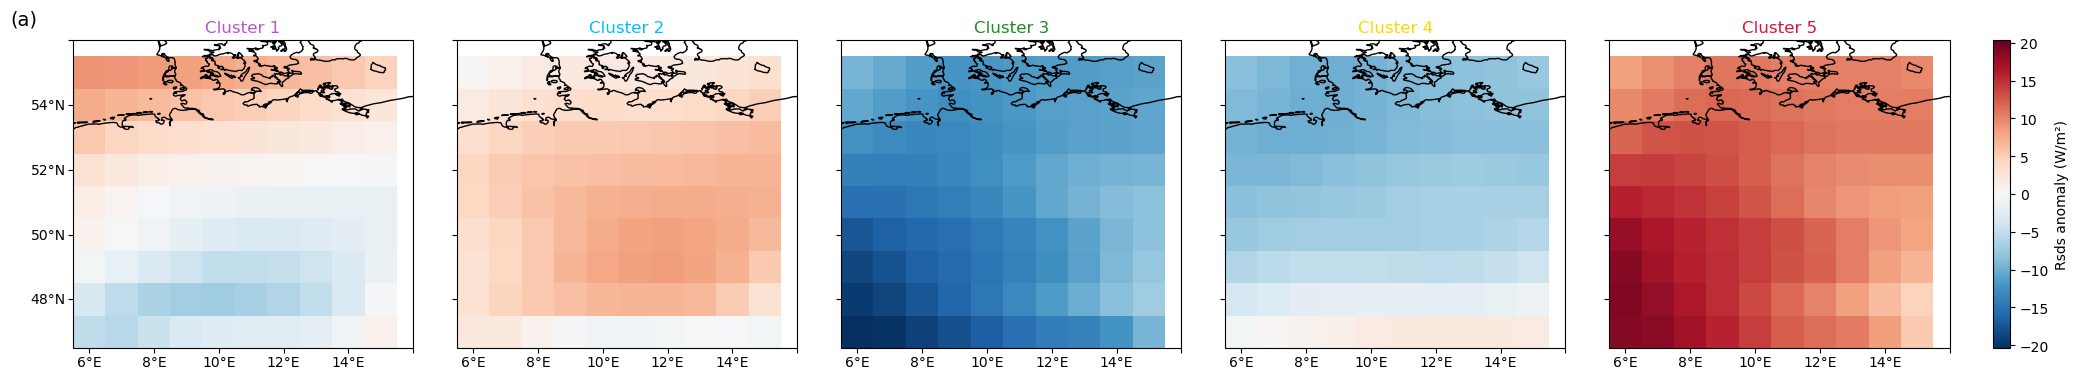

In [20]:

# Colors and desired number of subplots (mimic your example)
cluster_colors = ["mediumorchid", "deepskyblue", "forestgreen", "gold", "crimson"]
max_to_plot = 5  # plot first 5 clusters (as in example)

# Select clusters to plot (handle fewer than 5 gracefully)
clusters_all = np.array(composites['cluster'].values)
n_clusters = len(clusters_all)
n_plot = min(max_to_plot, n_clusters)
clusters_to_plot = clusters_all[:n_plot]

# Compute symmetric color limits (centered on zero)
# Use np.nanmin/np.nanmax on the values (convert to numpy; this is lazy for dask-backed arrays,
# you may want to .compute() beforehand if necessary).
vals = composites['rsds'].values
vmin = np.nanmin(vals)
vmax = np.nanmax(vals)
# make symmetric about zero (like your example)
absmax = max(abs(vmin), abs(vmax))
vmin = -absmax
vmax = absmax

# Levels similar to your example
nlevels = 20
levels = np.linspace(vmin, vmax, nlevels)

# Coordinates for contourf
lons = composites['lon'].values
lats = composites['lat'].values

# -------------------------
# Figure and GridSpec
# -------------------------
ncols = n_plot
nrows = 1
fig = plt.figure(figsize=(5 * ncols, 4))
gs = GridSpec(nrows, ncols + 1, width_ratios=[1] * ncols + [0.05], wspace=0.15)

cmap_name = "RdBu_r"
cmap_used = None

for i, cl in enumerate(clusters_to_plot):
    ax = fig.add_subplot(gs[0, i], projection=ccrs.PlateCarree())

    # select data for this cluster (2D lat x lon)
    da = composites['rsds'].sel(cluster=cl)

    # ensure the array ordering matches lats x lons
    # xarray will align automatically if we pass coords to pcolormesh
    cf = ax.pcolormesh(
        lons, lats, da.values,
        vmin=vmin, vmax=vmax,
        cmap=cmap_name, transform=ccrs.PlateCarree()
    )
    cmap_used = cf.cmap

    ax.coastlines()
    # follow your pattern for gridlines (assumes setup_gridlines() exists)
    if i == 0:
        setup_gridlines(ax, deg=2, alpha=0)
    else:
        setup_gridlines(ax, deg=2, alpha=0, ll=False)

    # Title using provided cluster color list (cycle if fewer/more)
    color = cluster_colors[i % len(cluster_colors)]
    ax.set_title(f"Cluster {int(cl) + 1}", fontsize=12, color=color)

# Add (a) label like your example (position may be adjusted)
fig.text(0.1, 0.92, "(a)", fontsize=14)

# Shared vertical colorbar (use last col in GridSpec)
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = ScalarMappable(norm=norm, cmap=cmap_used)
sm.set_array([])

cax = fig.add_subplot(gs[0, -1])
cbar = plt.colorbar(sm, cax=cax)
cbar.set_label('Rsds anomaly (W/m²)', fontsize=10)  # replace 'units' with actual units (e.g. m/s)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()
